# Loss-term ablation — leave-one-out retraining (full domain, 800×800)

Each loss term is removed and the production model **retrained from scratch** (300 epochs,
no early stopping, same seed), then compared to the full final recipe (baseline).
`+ high_weight` instead *adds* peak up-weighting (=8). Metrics: pooled RMSE (z0–11),
pattern correlation *r*, dispersion ratio σ, plus **per-layer** RMSE and *r*.
Data: `outputs/ablation_loss/loss_ablation_layer.json`. Noise floor ≈ ±0.01 RMSE.

## Part A — overall effect (pooled RMSE, r, σ)

In [1]:
import json, numpy as np, matplotlib.pyplot as plt
D=json.load(open('../../outputs/ablation_loss/loss_ablation_layer.json'))
ZH=[15,25,35,45,55,75,95,115,135,155,175,195]
LAB={'no_anom':'- anomaly','no_grad':'- gradient','no_pattern':'- pattern','no_spectral':'- spectral',
     'no_nonneg':'- non-negativity','hw8':'+ high_weight=8'}
ORDER=['no_anom','no_grad','no_pattern','no_spectral','no_nonneg','hw8']
b=D['base']['pooled']
print(f'baseline (full loss): RMSE {b["rmse"]:.3f}   r {b["r"]:.3f}   sigma {b["sigma"]:.3f}\n')
print(f'{"variant":>18} {"RMSE":>7} {"%dRMSE":>8} {"r":>7} {"%dr":>7} {"sigma":>6}')
print("-"*58)
for k in ORDER:
    m=D[k]['pooled']
    print(f'{LAB[k]:>18} {m["rmse"]:>7.3f} {100*(m["rmse"]-b["rmse"])/b["rmse"]:>+7.1f}% {m["r"]:>7.3f} {100*(m["r"]-b["r"])/b["r"]:>+6.1f}% {m["sigma"]:>6.3f}')

baseline (full loss): RMSE 0.755   r 0.887   sigma 0.903

           variant    RMSE   %dRMSE       r     %dr  sigma
----------------------------------------------------------
         - anomaly   0.779    +3.1%   0.875   -1.4%  0.903
        - gradient   0.772    +2.2%   0.876   -1.3%  0.863
         - pattern   0.766    +1.3%   0.868   -2.2%  0.876
        - spectral   0.752    -0.5%   0.867   -2.3%  0.921
  - non-negativity   0.764    +1.2%   0.885   -0.2%  0.893
   + high_weight=8   0.782    +3.5%   0.888   +0.2%  0.915


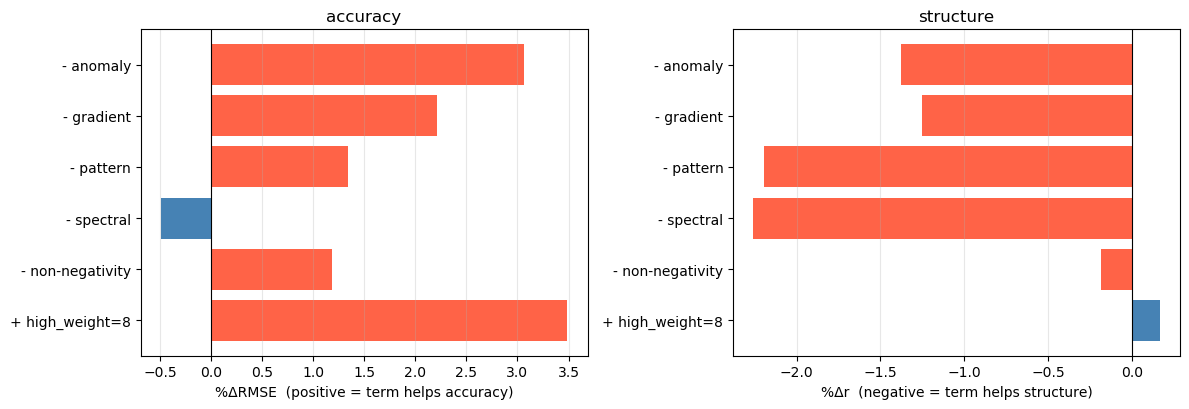

In [2]:
fig,axes=plt.subplots(1,2,figsize=(12,4.2))
names=[LAB[k] for k in ORDER]
pr=[100*(D[k]['pooled']['rmse']-b['rmse'])/b['rmse'] for k in ORDER]
pp=[100*(D[k]['pooled']['r']-b['r'])/b['r'] for k in ORDER]
axes[0].barh(names[::-1],pr[::-1],color=['tomato' if v>0 else 'steelblue' for v in pr[::-1]])
axes[0].set_xlabel('%ΔRMSE  (positive = term helps accuracy)'); axes[0].set_title('accuracy')
axes[1].barh(names[::-1],pp[::-1],color=['tomato' if v<0 else 'steelblue' for v in pp[::-1]])
axes[1].set_xlabel('%Δr  (negative = term helps structure)'); axes[1].set_title('structure')
for ax in axes: ax.axvline(0,color='k',lw=0.8); ax.grid(True,alpha=0.3,axis='x')
plt.tight_layout(); plt.show()

## Part B — per-layer effect (where each term matters)

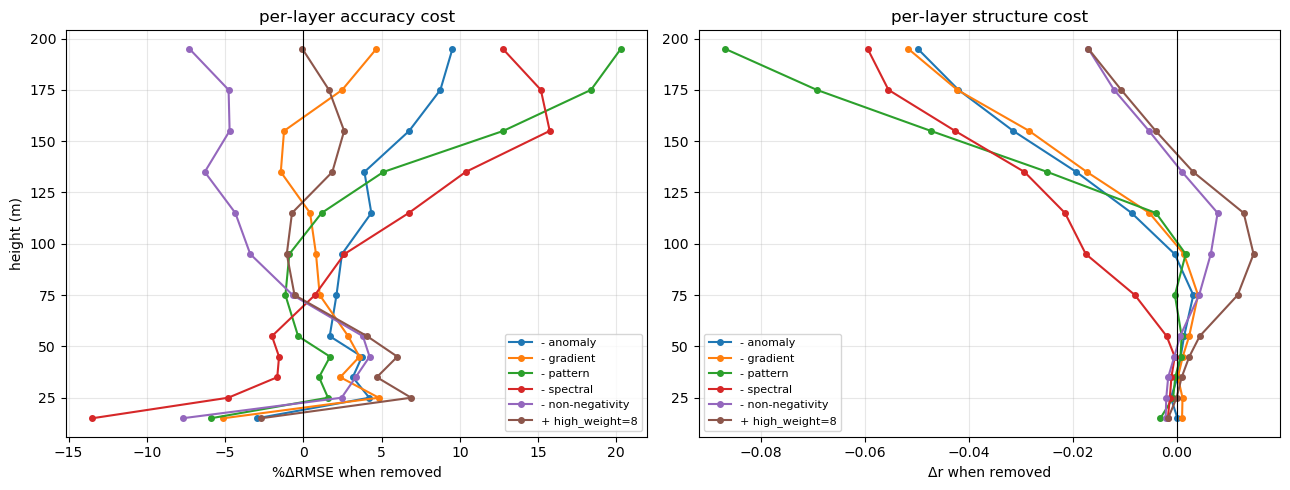

In [3]:
fig,axes=plt.subplots(1,2,figsize=(13,5))
for k in ORDER:
    pdr=[100*(D[k]['layer'][str(z)]['rmse']-D['base']['layer'][str(z)]['rmse'])/D['base']['layer'][str(z)]['rmse'] for z in range(12)]
    dpp=[D[k]['layer'][str(z)]['r']-D['base']['layer'][str(z)]['r'] for z in range(12)]
    axes[0].plot(pdr,ZH,'o-',label=LAB[k],ms=4)
    axes[1].plot(dpp,ZH,'o-',label=LAB[k],ms=4)
axes[0].set_xlabel('%ΔRMSE when removed'); axes[0].set_ylabel('height (m)'); axes[0].set_title('per-layer accuracy cost')
axes[1].set_xlabel('Δr when removed'); axes[1].set_title('per-layer structure cost')
for ax in axes: ax.axvline(0,color='k',lw=0.8); ax.grid(True,alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [4]:
# full per-layer matrix — every loss term (cols) × every layer (rows)
SHORT={'no_anom':'anom','no_grad':'grad','no_pattern':'patt','no_spectral':'spec','no_nonneg':'nng','hw8':'+hw8'}
def matrix(metric, title, fmt):
    print(title)
    print(f'{"h":>5} '+' '.join(f'{SHORT[k]:>6}' for k in ORDER))
    print('-'*(6+7*len(ORDER)))
    for z in range(12):
        bb=D['base']['layer'][str(z)][metric]
        cells=[fmt(D[k]['layer'][str(z)][metric], bb) for k in ORDER]
        print(f'{ZH[z]:>4}m '+' '.join(f'{c:>6}' for c in cells))
    print()
matrix('rmse','%ΔRMSE by layer (row) × loss term removed (col)  [positive = term helps accuracy]',
       lambda m,b: f'{100*(m-b)/b:+.0f}')
matrix('r','Δr×100 by layer (row) × loss term removed (col)  [negative = term helps structure]',
       lambda m,b: f'{100*(m-b):+.1f}')

%ΔRMSE by layer (row) × loss term removed (col)  [positive = term helps accuracy]
    h   anom   grad   patt   spec    nng   +hw8
------------------------------------------------
  15m     -3     -5     -6    -13     -8     -3
  25m     +4     +5     +2     -5     +2     +7
  35m     +3     +2     +1     -2     +3     +5
  45m     +4     +4     +2     -2     +4     +6
  55m     +2     +3     -0     -2     +4     +4
  75m     +2     +1     -1     +1     -1     -1
  95m     +2     +1     -1     +3     -3     -1
 115m     +4     +0     +1     +7     -4     -1
 135m     +4     -1     +5    +10     -6     +2
 155m     +7     -1    +13    +16     -5     +3
 175m     +9     +2    +18    +15     -5     +2
 195m    +10     +5    +20    +13     -7     -0

Δr×100 by layer (row) × loss term removed (col)  [negative = term helps structure]
    h   anom   grad   patt   spec    nng   +hw8
------------------------------------------------
  15m   +0.0   +0.1   -0.3   -0.2   -0.2   -0.2
  25m   -0.1   +

In [5]:
# per-layer table for one term (edit KEY)
KEY='no_pattern'
print(f'{LAB[KEY]}  — per-layer (baseline vs removed)')
print(f'{"height":>7} {"RMSE_base":>9} {"RMSE_rm":>8} {"%dRMSE":>7} {"r_base":>7} {"r_rm":>6} {"dr":>7}')
print("-"*56)
for z in range(12):
    bb=D['base']['layer'][str(z)]; mm=D[KEY]['layer'][str(z)]
    print(f'{ZH[z]:>5}m {bb["rmse"]:>9.3f} {mm["rmse"]:>8.3f} {100*(mm["rmse"]-bb["rmse"])/bb["rmse"]:>+6.1f}% {bb["r"]:>7.3f} {mm["r"]:>6.3f} {mm["r"]-bb["r"]:>+7.3f}')

- pattern  — per-layer (baseline vs removed)
 height RMSE_base  RMSE_rm  %dRMSE  r_base   r_rm      dr
--------------------------------------------------------
   15m     2.454    2.309   -5.9%   0.955  0.952  -0.003
   25m     2.086    2.119   +1.6%   0.947  0.946  -0.001
   35m     1.599    1.615   +1.0%   0.945  0.944  -0.000
   45m     1.267    1.289   +1.7%   0.940  0.941  +0.001
   55m     1.092    1.089   -0.3%   0.930  0.931  +0.001
   75m     0.753    0.744   -1.1%   0.889  0.889  -0.000
   95m     0.563    0.558   -0.9%   0.852  0.854  +0.002
  115m     0.446    0.451   +1.2%   0.829  0.825  -0.004
  135m     0.377    0.396   +5.1%   0.832  0.807  -0.025
  155m     0.320    0.361  +12.8%   0.841  0.794  -0.047
  175m     0.284    0.336  +18.4%   0.844  0.775  -0.069
  195m     0.260    0.313  +20.3%   0.839  0.752  -0.087
